✅ Dataset loaded successfully!


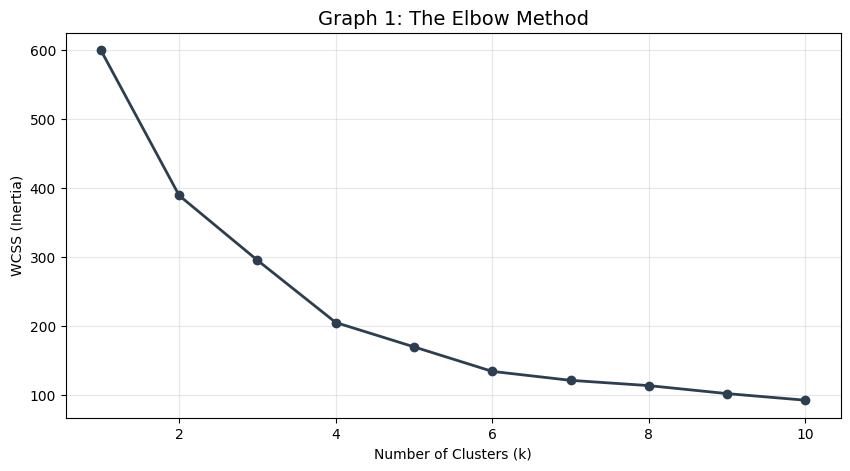

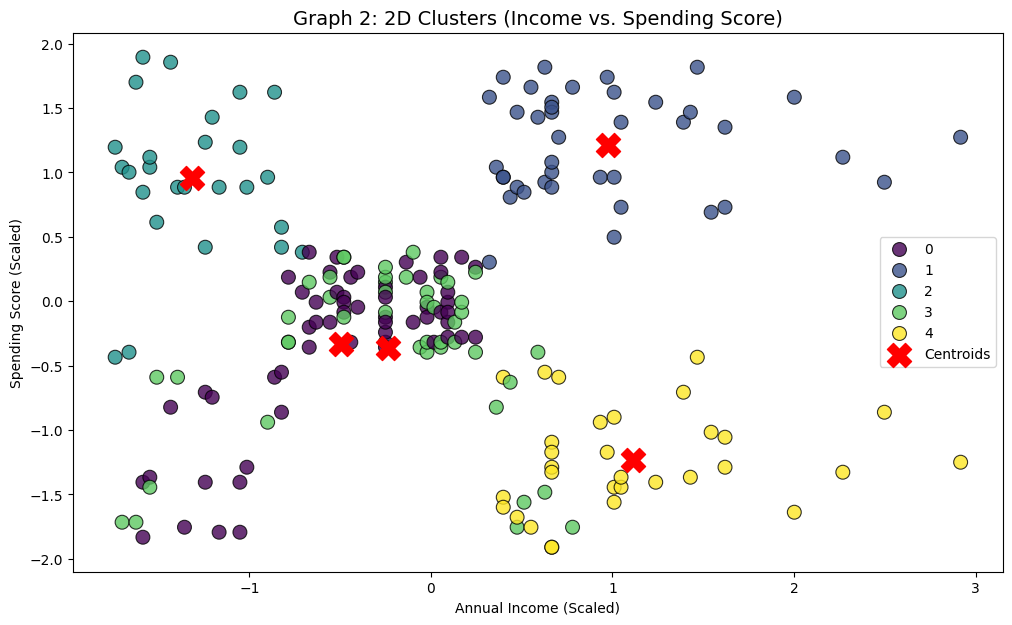

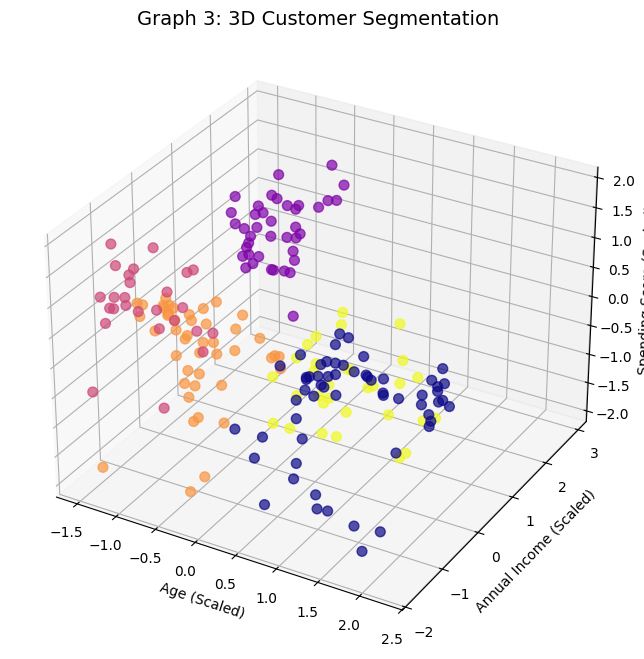

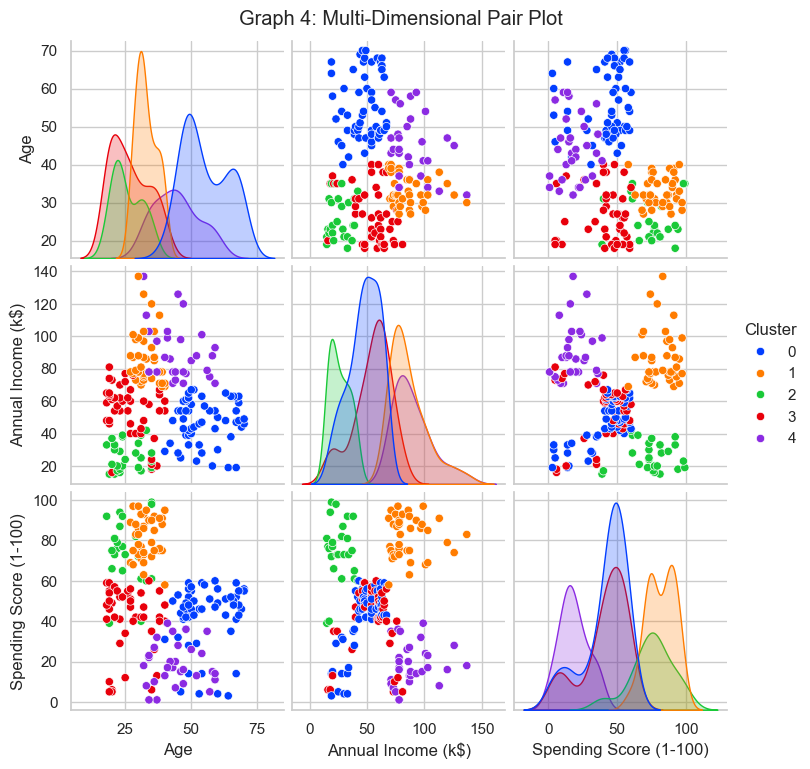

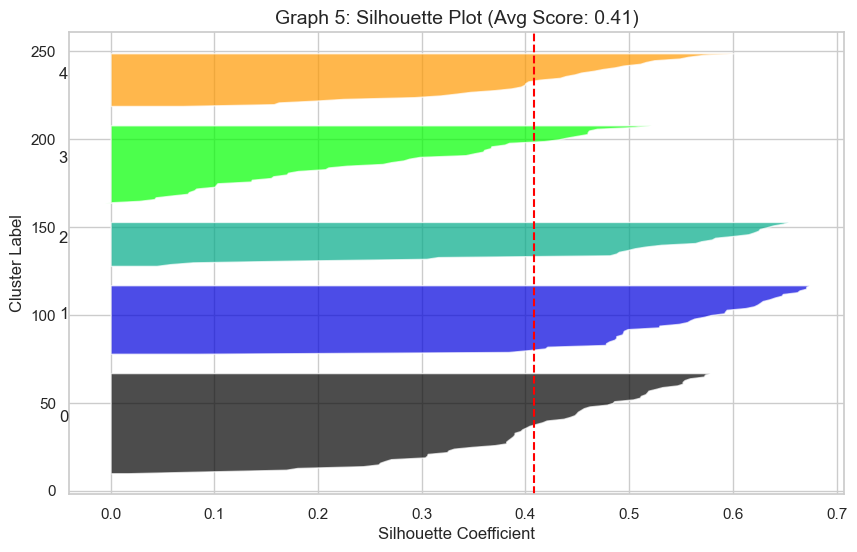


   CLUSTER SUMMARY STATS
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        55.275862           47.620690               41.706897
1        32.875000           86.100000               81.525000
2        25.769231           26.115385               74.846154
3        26.733333           54.311111               40.911111
4        44.387097           89.774194               18.483871


In [2]:
import os
# 0. WINDOWS FIX: Prevents the joblib/wmic error in specific environments
os.environ["LOKY_MAX_CPU_COUNT"] = "4" 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples, silhouette_score

# 1. LOAD DATASET
try:
    df = pd.read_csv('Mall_Customers.csv')
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ Error: Mall_Customers.csv not found. Ensure it's in the same folder.")
    exit()

# 2. SELECT FEATURES & SCALING
# We'll use Age, Income, and Spending Score for the full analysis
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. THE ELBOW METHOD (Finding Optimal K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)



plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#2c3e50', linewidth=2)
plt.title('Graph 1: The Elbow Method', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.3)
plt.show()

# 4. TRAINING THE FINAL MODEL (K=5)
k = 5
model = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
cluster_labels = model.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

# 5. 2D VISUALIZATION (Income vs Spending)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=X_scaled[:, 1], y=X_scaled[:, 2], 
    hue=cluster_labels, palette='viridis', s=100, edgecolor='black', alpha=0.8
)
# Plotting Centroids for Income and Spending (indices 1 and 2)
centroids = model.cluster_centers_
plt.scatter(centroids[:, 1], centroids[:, 2], s=300, c='red', marker='X', label='Centroids')



plt.title('Graph 2: 2D Clusters (Income vs. Spending Score)', fontsize=14)
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

# 6. 3D VISUALIZATION (Age, Income, Spending)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], 
                     c=cluster_labels, cmap='plasma', s=50, alpha=0.7)

ax.set_title('Graph 3: 3D Customer Segmentation', fontsize=14)
ax.set_xlabel('Age (Scaled)')
ax.set_ylabel('Annual Income (Scaled)')
ax.set_zlabel('Spending Score (Scaled)')
plt.show()

# 7. SEABORN PAIR PLOT (Relationships between all variables)
sns.set_theme(style="whitegrid")
pair_plot = sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']], 
                         hue='Cluster', palette='bright', diag_kind='kde')
pair_plot.fig.suptitle('Graph 4: Multi-Dimensional Pair Plot', y=1.02)
plt.show()

# 8. SILHOUETTE ANALYSIS (Validation Graph)
score = silhouette_score(X_scaled, cluster_labels)
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)



plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(k):
    ith_cluster_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / k)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, facecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=score, color="red", linestyle="--")
plt.title(f'Graph 5: Silhouette Plot (Avg Score: {score:.2f})', fontsize=14)
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster Label')
plt.show()

# 9. FINAL SUMMARY REPORT
print("\n" + "="*30)
print("   CLUSTER SUMMARY STATS")
print("="*30)
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
print(df.groupby('Cluster')[numeric_cols].mean())

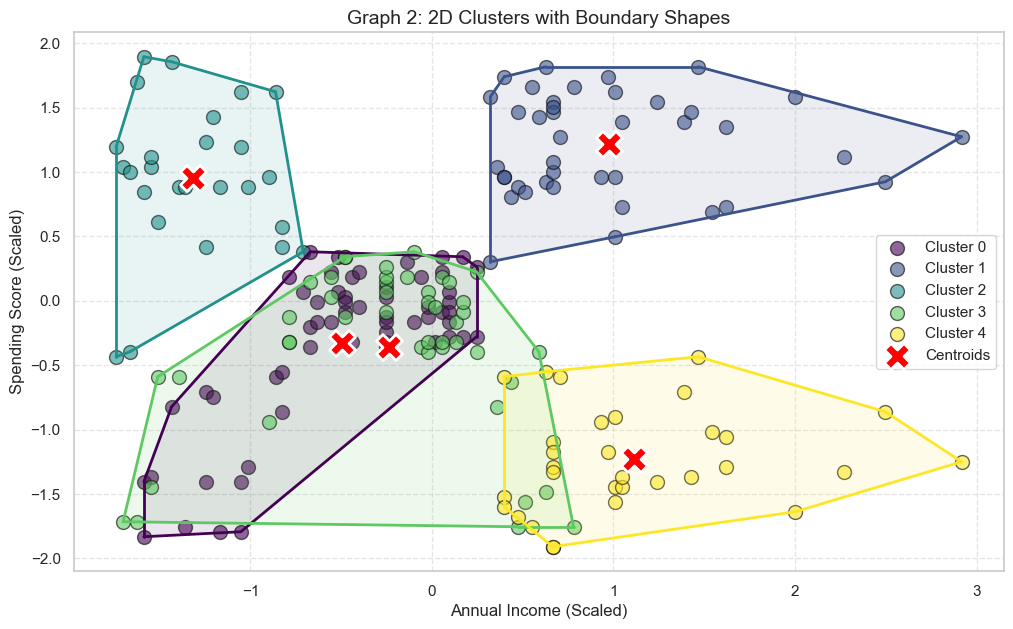

In [3]:
from scipy.spatial import ConvexHull

# 5. 2D VISUALIZATION (Income vs Spending) with Boundaries
plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0, 1, k))

# Loop through each cluster to plot points and boundaries
for i in range(k):
    # Get points for this specific cluster
    points = X_scaled[cluster_labels == i][:, [1, 2]] # Column 1 (Income) and 2 (Spending)
    
    # Plot the scatter points
    plt.scatter(points[:, 0], points[:, 1], s=100, label=f'Cluster {i}', 
                color=colors[i], edgecolor='black', alpha=0.6)
    
    # Calculate and plot the Convex Hull (the "shape" around the points)
    if len(points) > 2:  # Hull needs at least 3 points
        hull = ConvexHull(points)
        for simplex in hull.simplices:
            plt.plot(points[simplex, 0], points[simplex, 1], color=colors[i], lw=2)
        
        # Optional: Fill the shape with a light color
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], color=colors[i], alpha=0.1)

# Plotting Centroids
centroids = model.cluster_centers_
plt.scatter(centroids[:, 1], centroids[:, 2], s=350, c='red', marker='X', 
            label='Centroids', edgecolor='white', linewidth=2)

plt.title('Graph 2: 2D Clusters with Boundary Shapes', fontsize=14)
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_30236\954015952.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Age', data=df, palette='viridis')


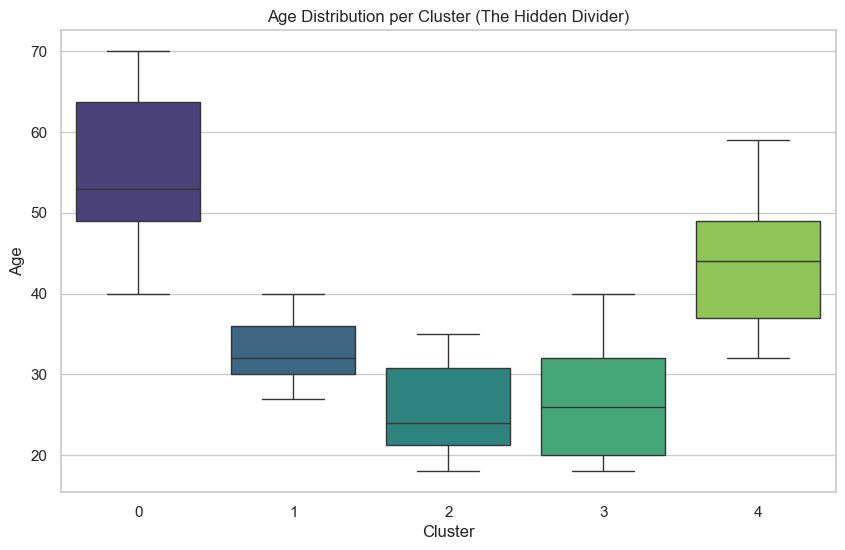

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing why the overlap exists in 2D by showing the Age difference
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Age', data=df, palette='viridis')
plt.title('Age Distribution per Cluster (The Hidden Divider)')
plt.show()